## -----------------------------------------------------------------------------
## INITIALIZATION
## -----------------------------------------------------------------------------
useful lines:

with_rx.printSchema()

train_df.select("ENROLID").distinct().count()

df_2018.groupBy("cost_stratum_2018").count().orderBy("cost_stratum_2018").show()


In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/21 09:15:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/21 09:15:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2025-08-21 09:15:14,206 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/08/21 09:15:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-08-21 09:15:15,881 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-08-21 09:15:17,734 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-08-21 09:15:17,735 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-08-21 09:15

# Load Data

In [4]:
highcost_cutoff = 4
stratifier_cutoff = 3

import importlib
import model_pipeline
importlib.reload(model_pipeline)
len(df_claims.columns)


85

In [4]:
############### merge 2017/18 with 2018/19 cohorts and add suffix to repeated ENROLID
from pyspark.sql.functions import concat_ws, col
df_2018 =spark.read.format("parquet").load( "0813_adherence_features_2017.parquet")
# df_2018 =spark.read.format("parquet").load( "0813_cost_features_2017.parquet")
#df_2018 =spark.read.format("parquet").load( "df_0714_2017_18_with_THERCLS.parquet")

#df_2019 =spark.read.format("parquet").load( "df_0714_2018_19_with_THERCLS.parquet")
#df_2018_str = df_2018.withColumn("ENROLID", F.col("ENROLID").cast("string"))
#df_2019_str = df_2019.withColumn("ENROLID", F.concat_ws("_", F.col("ENROLID").cast("string"), F.lit("2019")))

#df_full = df_2018_str.unionByName(df_2019_str)
#print("Duplicated ENROLIDs")
#df_full.groupBy("ENROLID").count().filter("count > 1").show()

# 1) pull Spark DF into pandas
df_og = df_2018.toPandas()
df_og["INDSTRY"] = df_og["INDSTRY"].fillna("-1")
df_og.drop(columns = [ 'first_ckd_date', 'ckd_visit_count', 'quarters_with_labs','nephrology_visit_count', 'days_to_nephrology','first_nephrology_date',],inplace=True)



# Baseline Model

In [ ]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = ['2017Q1', '2017Q2', '2017Q3', '2017Q4',"stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage', ]
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', ]
print(CAT_COLUMNS)

leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
Number of leftover columns: 0
[] (33590, 86)


### Creating the high-cost cutoff binary variable and feature cols


In [ ]:
df_og["high_cost_2018"] = (df_og["cost_stratum_2018"] >= highcost_cutoff).astype(int)
feature_cols = [c for c in df_og.columns
              if c not in  ("ENROLID","cost_stratum_2018", "high_cost_2018")]    # keep only predictors
numeric_cols = df_og[feature_cols + ["high_cost_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["high_cost_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "high_cost_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features to drop: ",high_corr_cols)
# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,test_size=0.3,verbose=False)

print(train_pd.shape,test_pd.shape)
# 3) build and train

rf_pipe = model_pipeline.get_random_forest_pipeline(df=train_pd[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS)
rf_pipe = model_pipeline.get_logistic_pipeline(df=train_pd[feature_cols],categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,max_iter = 1000,scale_post_preprocess=True)
rf_pipe = model_pipeline.get_histgb_pipeline(df=train_pd[feature_cols],
categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, calibration_method = None)
rf_pipe.fit(train_pd[feature_cols], train_pd["high_cost_2018"])


model_pipeline.evaluate_model_auc(
    rf_pipe,
    test_pd[feature_cols],
test_pd["high_cost_2018"], highcost_cutoff=highcost_cutoff)


High corr features to drop:  []
(23513, 86) (10077, 86)
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness

# Stratification

In [1]:
#import interpretableai
#interpretableai.install()
from interpretableai import iai


In [ ]:
import interpretableai
interpretableai.install_julia()
interpretableai.install_system_image()

[ Info: Julia version info


Julia Version 1.11.6
Commit 9615af0f269 (2025-07-09 12:58 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: macOS (arm64-apple-darwin24.0.0)
  uname: Darwin 24.6.0 Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:55 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T6031 arm64 arm
  CPU: Apple M3 Ultra: 
                 speed         user         nice          sys         idle          irq
       #1-32  2400 MHz   12890623 s          0 s    4432433 s  329636879 s          0 s
  Memory: 512.0 GB (334461.046875 MB free)
  Uptime: 1.084944e6 sec
  Load Avg:  6.77880859375  3.66552734375  2.8896484375
  WORD_SIZE: 64
  LLVM: libLLVM-16.0.6 (ORCJIT, apple-m2)
Threads: 1 default, 0 interactive, 1 GC (on 24 virtual cores)
Environment:
  PATH = /Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/bin:/Users/cat2510/.cursor-server/bin/ef5eeb47a684b4c217dfaf0463aa7ea952f8ab90/bin/remote-cli:/Users/cat2510/.juliaup/bin:/opt/spark/bin:/opt/homebrew/opt/openjdk@17/bin:/op

[ Info: Julia executable: /Users/cat2510/Library/Application Support/InterpretableAI/julia/1.11.6/julia-1.11.6/bin/julia
[ Info: Trying to import PyCall...
┌ Info: PyCall is already installed and compatible with Python executable.
│ 
│ PyCall:
│     python: /Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/bin/python
│     libpython: /Users/cat2510/.pyenv/versions/3.11.0/lib/libpython3.11.dylib
│ Python:
│     python: /Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/bin/python
└     libpython: /Users/cat2510/.pyenv/versions/3.11.0/lib/libpython3.11.dylib
Installed Julia to /Users/cat2510/Library/Application Support/InterpretableAI/julia/1.11.6/julia-1.11.6


In order to continue the installation process, please review the license agreement.


In [57]:
df_pd = df_og.copy()
#print(df_pd["stage_2017"].value_counts(dropna=False))
#df_pd.head()

In [58]:
#stratifier_train_pd = df_pd[df_pd["stage_2017"] > 3]
stratifier_train_pd = df_pd[df_pd["stage_2017"] <= 3]
print("Stratifier trained on subgroup of size ",len(stratifier_train_pd))
stratification_cols = [c for c in feature_cols
              if c not in  STAGE_COLUMNS]    # keep only predictors
STAGE_COLUMNS


Stratifier trained on subgroup of size  28591


['2017Q1',
 '2017Q2',
 '2017Q3',
 '2017Q4',
 'stage_2017',
 '2017Q1_max_ckd_stage',
 '2017Q2_max_ckd_stage',
 '2017Q3_max_ckd_stage',
 '2017Q4_max_ckd_stage']

In [59]:
# stratifier_train_pd["y_high"] =  stratifier_train_pd["high_cost_2018"]
stratifier_train_pd["y_high"] = (df_og["cost_stratum_2018"] >= stratifier_cutoff).astype(int)

# 3) Train/Test split (optional; here we train on all Stage 3)
X_train = stratifier_train_pd[stratification_cols]
y_train = stratifier_train_pd["y_high"]


stratifier = model_pipeline.get_logistic_pipeline(df=X_train,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS,max_iter = 500,scale_post_preprocess=True,calibrate=False)
stratifier.fit(X_train, y_train)

# ─── 5) Apply to the full cohort ─────────────────────────────────────────────
X_full = df_pd[stratification_cols]
proba_high = stratifier.predict_proba(X_full)[:,1]
df_pd["proba_high_2018"] = proba_high
print("Inference on full cohort of size: ", len(proba_high))

→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_87479/4191489859.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros



# Matching

In [60]:
import balancing_functions.match_control

from balancing_functions.match_control import *
importlib.reload(balancing_functions.match_control)

sampler = RiskBinnedCaseControlResampler(
    random_state=42,
    uid_col="ENROLID",
    binary_group="true_class",
    proba_col="proba_high_2018",
    keep_controls_if_no_cases=True,
    #bin_edges = [0.0,0.01, 0.025, 0.05,0.1,0.2,0.5,1.0]
)


df_binned = sampler.assign_bins(df_pd,)

# 2) Create your binary “true_class” from the stage_group
df_binned["true_class"] = (df_binned["stage_2017"] >3).astype(int)
#   – now true_class=1 are stage>3, and 0 are stage≤3
df_binned.drop(["cost_stratum_2018",'high_cost_2018'],axis=1,inplace=True)
df_binned.columns

Index(['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'has_Hypertension',
       'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia',
       'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism',
       'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency',
       'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea',
       '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017',
       'cost_stratum_2017', 'util_2017', 'THRCLS_53', 'THRCLS_51', 'THRCLS_52',
       'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 'THRCLS_172', 'THRCLS_174',
       'THRCLS_181', 'THRCLS_60', '2017Q1_ckd_cost', '2017Q1_ckd_claims',
       '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost',
       '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost',
       '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage',
       '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost',
       '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims',
       '2017Q3_max_ckd_stage', '20

In [63]:

train_df = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)

# (Optional) sanity check:
print("Train size:", len(train_df), "Test size:", len(test_df))
#print(train_df["risk_bin"].value_counts(normalize=True))
#print(test_df ["risk_bin"].value_counts(normalize=True))

bins = list(train_df["risk_bin"].cat.categories)   # already ordered

# 3️⃣  plot – no extra tricks needed
fig = px.histogram(
    train_df,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {stratifier_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)

fig.show()




Train size: 23513 Test size: 10077


In [64]:
# 5) Apply the by‐bin matching  
matched_train_df, removed_ids = sampler.apply_sampler_by_bin(train_df,global_ctrl_ratio=1.0,
    target_bin_quantile=None,
    max_ctrl_per_case=1 ) #extra_exclude_cols = STAGE_COLS+['stage_2017', 'stage_2018']
print("After matching, train size:", len(matched_train_df))
print("Per-bin counts in matched train:")
print(matched_train_df["risk_bin"].value_counts())
# matched_df now contains all “cases” (stage>3) each with exactly one matched “control” (stage≤3)



→ do_not_impute on : ['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity', 'risk_bin', 'ENROLID', 'true_class', 'proba_high_2018']
Imputing on features:  Index(['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
       'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
       'has_Hyperparathyroidism', 'has_Kidney_Transplant',
       'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
       'has_Hypothyroidism', 'has_Sleep_Apnea', '2017Q1', '2017Q2', '2017Q3',
       '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', 'THRCLS_53',
       'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47',
       'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60',
       '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage',
       '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost',
       '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims',
       '2017Q2_max_ckd_stage', '

/Users/cat2510/my_projects/balancing_functions/match_control.py:190: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Imputing on features:  Index(['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
       'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
       'has_Hyperparathyroidism', 'has_Kidney_Transplant',
       'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
       'has_Hypothyroidism', 'has_Sleep_Apnea', '2017Q1', '2017Q2', '2017Q3',
       '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', 'THRCLS_53',
       'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47',
       'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60',
       '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage',
       '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost',
       '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims',
       '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost',
       '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost',
       '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage',
       '2017Q3_direct_ckd_cost', '20

In [65]:
bins = [f"{x:.1f}-{x+0.1:.1f}" for x in np.arange(0.0, 1.0, 0.1)]

fig = px.histogram(
    matched_train_df,
    x="risk_bin",
    color="true_class",
    category_orders={"risk_bin": bins},   # good to keep
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {stratifier_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Matched Cohort: High-Cost Risk by 2017 CKD Stage Group",
    barmode="group",
    height=500, width=800
)

# *** pin the x-axis order ***
fig.update_xaxes(categoryorder="array", categoryarray=bins)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [66]:
# 1) Collapse to one row per ENROLID
matched_ids_df = (
    matched_train_df[["ENROLID"]]
      .drop_duplicates()
      .reset_index(drop=True)
)

# 2) Pull in the target from your original train set
matched_with_target = matched_ids_df.merge(
    train_pd[["ENROLID", "high_cost_2018"]],
    on="ENROLID",
    how="inner"
)
print(matched_with_target.shape)
print(CAT_COLUMNS)


(7030, 2)
['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']


# Model Comparisons

In [67]:
train_pd.shape, train_df.shape

((23513, 86), (23513, 87))

In [68]:
X_test = test_pd[feature_cols]
y_test = test_pd['high_cost_2018']
X_train, y_train = matched_train_df[feature_cols], matched_with_target['high_cost_2018']
#X_train, y_train = train_pd[feature_cols], train_pd['high_cost_2018']
# 5. Create and train models using your existing pipelines
# Logistic Regression model
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
log_pipeline.fit(X_train, y_train)

# Random Forest model
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
rf_pipeline.fit(X_train, y_train)

# Gradient Boosting model
gb_pipeline = model_pipeline.get_histgb_pipeline(
    df=matched_train_df[feature_cols]
,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS
)
gb_pipeline.fit(X_train,y_train)

# 6. Evaluate models (using your existing function)
print("\nLogistic Regression Results:")
model_pipeline.evaluate_model_auc(log_pipeline, X_test, y_test,highcost_cutoff=highcost_cutoff)

print("\nRandom Forest Results:")
model_pipeline.evaluate_model_auc(rf_pipeline, X_test, y_test,highcost_cutoff=highcost_cutoff)

print("\nGradient Boosting Results:")
model_pipeline.evaluate_model_auc(gb_pipeline, X_test, y_test,highcost_cutoff=highcost_cutoff)


→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 


Analyzing Logistic Regression feature importance...


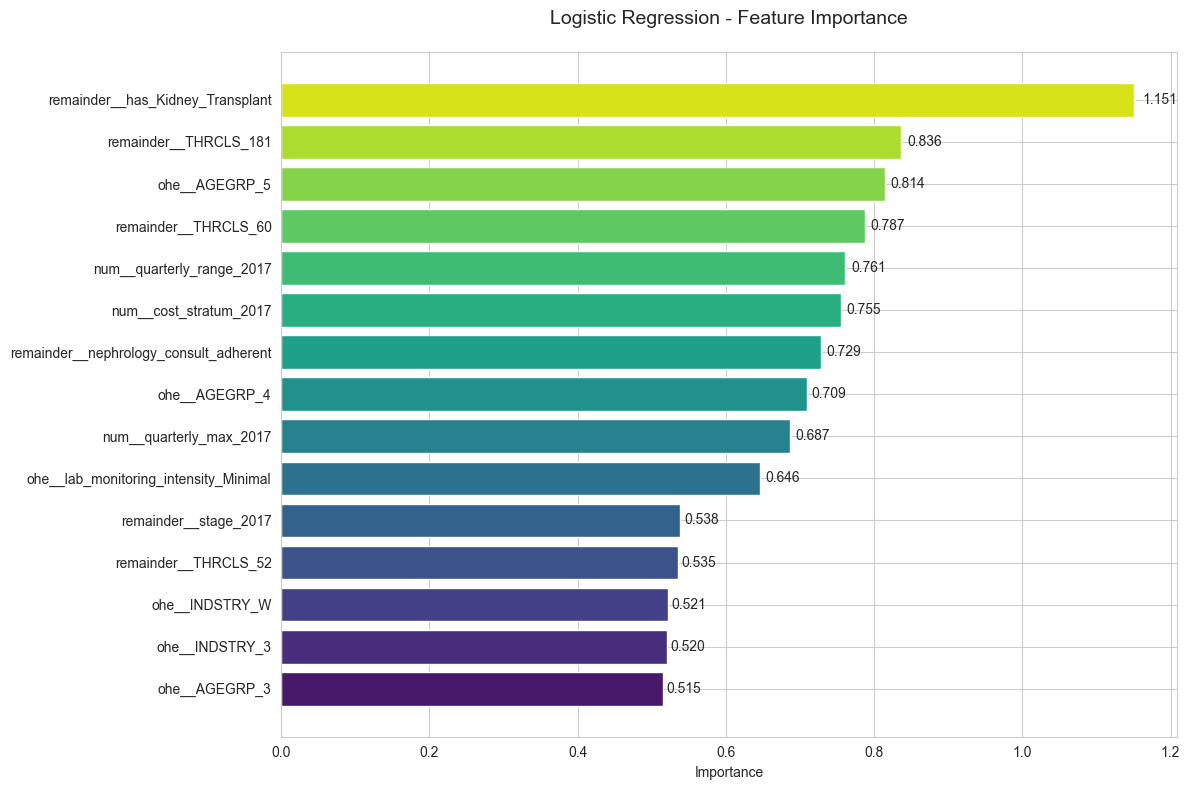

Top 10 features from Logistic Regression:
                            feature  importance
0  remainder__has_Kidney_Transplant    1.150912

Analyzing Random Forest feature importance...


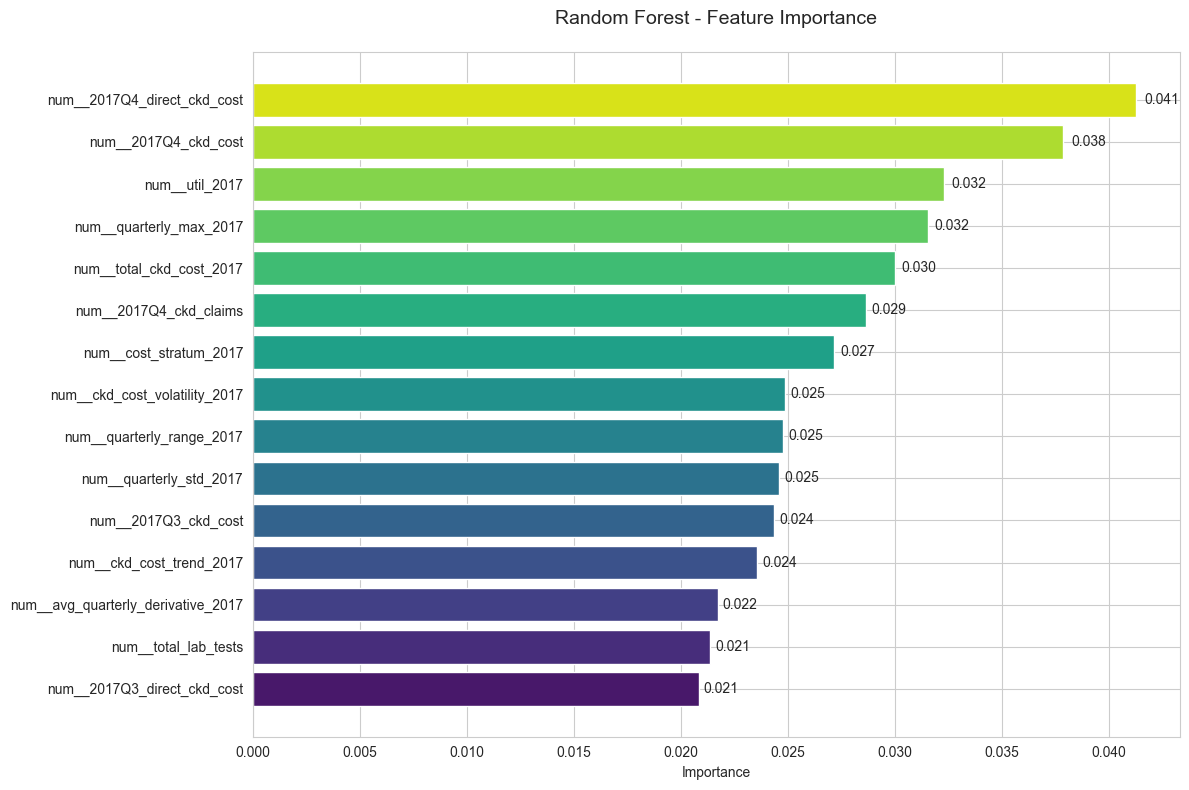

Top 10 features from Random Forest:
                       feature  importance
0  num__2017Q4_direct_ckd_cost    0.041272

Analyzing Gradient Boosting feature importance...


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but HistGradientBoostingClassifier was fitted without feature names



ValueError: X has 83 features, but HistGradientBoostingClassifier is expecting 103 features as input.

In [71]:
import feature_importance
importlib.reload(feature_importance)
importlib.reload(model_pipeline)

# Logistic Regression feature importance
print("\nAnalyzing Logistic Regression feature importance...")
log_fig, log_importance = feature_importance.analyze_feature_importance(
    log_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Logistic Regression - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Logistic Regression:")
print(log_importance.head(1))

# Random Forest feature importance
print("\nAnalyzing Random Forest feature importance...")
rf_fig, rf_importance = feature_importance.analyze_feature_importance(
    rf_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Random Forest - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Random Forest:")
print(rf_importance.head(1))

# Gradient Boosting feature importance
print("\nAnalyzing Gradient Boosting feature importance...")
gb_fig, gb_importance = feature_importance.analyze_feature_importance(
    gb_pipeline, X_train, y_train, X_test, y_test,
    method='permutation', top_n=15, 
    title="Gradient Boosting - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Gradient Boosting:")
print(gb_importance.head(1))


In [ ]:
# Gradient Boosting feature importance
print("\nAnalyzing Gradient Boosting feature importance...")
gb_fig, gb_importance = feature_importance.analyze_feature_importance(
    gb_pipeline, X_train, y_train, X_test, y_test,
    method='permutation', top_n=15, 
    title="Gradient Boosting - Feature Importance",
)
plt.show()
print("Top 10 features from Gradient Boosting:")
print(gb_importance.head(10))


# Model Diagnoses

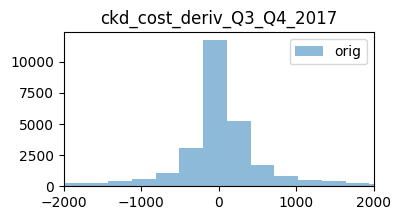

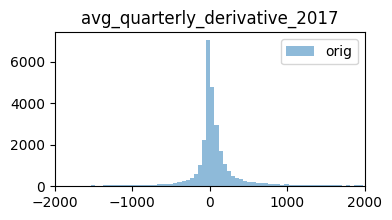

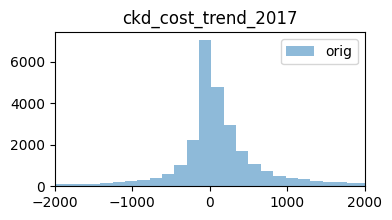

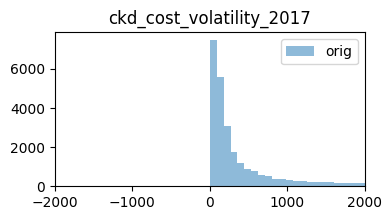

In [85]:
import matplotlib.pyplot as plt

for feat in ["ckd_cost_deriv_Q3_Q4_2017","avg_quarterly_derivative_2017",'ckd_cost_trend_2017', 'ckd_cost_volatility_2017']:
    plt.figure(figsize=(4,2))
    plt.hist(df_og[feat], bins=10000, alpha=0.5, label="orig", density=False)
    plt.title(feat)
    plt.xlim([-2000,2000])
    plt.legend()
    plt.show()


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


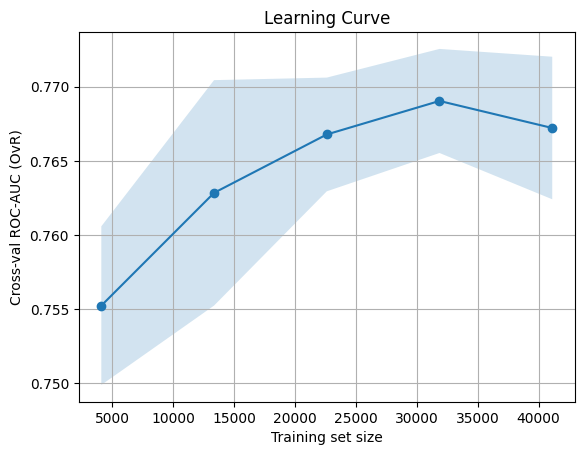

In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_pipe,train_pd[feature_cols], train_pd["cost_stratum_2018"], train_sizes=np.linspace(0.1,1.0,5),
    cv=5, scoring="roc_auc_ovr", n_jobs=-1,
    shuffle=True,
    random_state=42
)

# plot
plt.plot(train_sizes, test_scores.mean(axis=1), marker="o")
plt.fill_between(train_sizes,
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1),
                 alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Cross-val ROC-AUC (OvR)")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

In [47]:
len(train_pd)

51412

In [22]:
high_cost_test = test_pd[test_pd["high_cost_2018"]==1]
low_cost_test = test_pd[test_pd["high_cost_2018"]==0]
high_cost_test[BIN_FLAG_COLUMNS]

,has_Hypertension,has_Type_2_Diabetes,has_Anemia,has_Hyperlipidemia,has_Acute_Kidney_Failure,has_Hyperparathyroidism,has_Kidney_Transplant,has_Vitamin_D_Deficiency,has_Long-term_Drug_Therapy,has_Hypothyroidism,...,THRCLS_53,THRCLS_51,THRCLS_52,THRCLS_69,THRCLS_46,THRCLS_47,THRCLS_172,THRCLS_174,THRCLS_181,THRCLS_60
13,1,0,1,0,1,0,1,0,1,0,...,0,0,1,0,0,1,0,0,1,1
72,1,1,0,1,0,1,0,0,1,1,...,1,1,1,1,0,0,1,1,0,1
79,1,1,0,1,1,0,0,0,0,0,...,1,1,1,0,1,0,1,1,0,1
114,1,1,1,1,0,1,0,1,0,0,...,1,1,1,0,1,0,0,1,0,1
323,1,1,1,1,1,0,0,0,0,0,...,1,1,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21846,1,0,1,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
21852,0,0,1,0,0,0,0,0,0,1,...,0,1,1,0,1,0,0,0,0,1
21906,1,1,1,0,0,0,1,0,0,0,...,0,0,1,0,1,0,1,0,1,0
21924,1,1,1,1,1,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,1


In [23]:
low_cost_test.has_Hypertension.value_counts(dropna=False)

has_Hypertension
1    18416
0     3174
Name: count, dtype: int64

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_41822/3827913560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


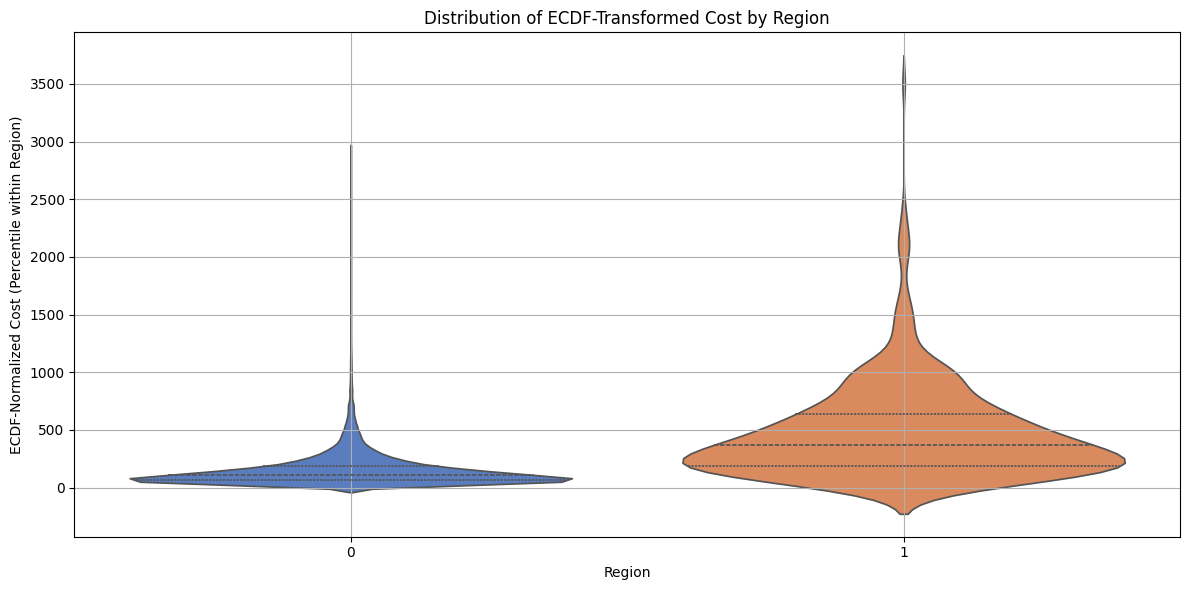

In [25]:
import seaborn as sns# Plot ECDF-transformed cost distribution by region
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=test_pd,
    x="high_cost_2018",
    y="util_2017",
    inner="quartile",
    palette="muted"
)
plt.title("Distribution of ECDF-Transformed Cost by Region")
plt.ylabel("ECDF-Normalized Cost (Percentile within Region)")
plt.xlabel("Region")
plt.grid(True)
plt.tight_layout()
plt.show()